In [ ]:
!pip install torch_geometric

import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 71.3 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
PyG version: 2.7.0
GPU available: True


##Loading Dataset and cleaning it

In [ ]:
from torch_geometric.datasets import FB15k_237

dataset = FB15k_237(root='./data/FB15k-237')

# dataset[0] gives us the training nodes and edges
data = dataset[0]

print(f"Dataset: {dataset.__class__.__name__}")
print(f"Number of Entities (Nodes): {data.num_nodes}")
# total number of relation
num_relation_types = data.edge_type.max().item() + 1
print(f"Number of Relation Types (Edge Types): {num_relation_types}")
print(f"Total Triplets (Edges) in training: {data.num_edges}")

print("\n--- Graph Structure Tensors ---")
print(f"Edge Index shape: {data.edge_index.shape}")
print(f"Edge Type shape: {data.edge_type.shape}")

Processing...


Dataset: FB15k_237
Number of Entities (Nodes): 14541
Number of Relation Types (Edge Types): 237
Total Triplets (Edges) in training: 272115

--- Graph Structure Tensors ---
Edge Index shape: torch.Size([2, 272115])
Edge Type shape: torch.Size([272115])


Done!


#Model-1 R-GCN

##R-GCN Class

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import RGCNConv

class RGCNLinkPredictor(nn.Module):
    def __init__(self, num_nodes, num_relations, hidden_channels, num_bases):
        super(RGCNLinkPredictor, self).__init__()

        # Initial Embeddings
        self.node_emb = nn.Embedding(num_nodes, hidden_channels)
        self.rel_emb = nn.Embedding(num_relations, hidden_channels)

        # R-GCN Encoder Layers
        self.conv1 = RGCNConv(hidden_channels, hidden_channels, num_relations, num_bases=num_bases)
        self.conv2 = RGCNConv(hidden_channels, hidden_channels, num_relations, num_bases=num_bases)

    def encode(self, edge_index, edge_type):
        x = self.node_emb.weight

        x = self.conv1(x, edge_index, edge_type)
        x = F.relu(x)

        x = F.dropout(x, p=0.2, training=self.training)

        x = self.conv2(x, edge_index, edge_type)

        return x

    #distmult decoder
    def decode(self, head_emb, rel_idx, tail_emb):
        r_emb = self.rel_emb(rel_idx)
        score = torch.sum(head_emb * r_emb * tail_emb, dim=-1)
        return score


    ## Use this for transE decoder

    # def decode(self, head_emb, rel_idx, tail_emb):
    #     # Retrieve the embedding for the specific relation type
    #     r_emb = self.rel_emb(rel_idx)

    #
    #     # 1. Calculate the expected position: head + relation
    #     expected_tail = head_emb + r_emb

    #
    #     # We use L1 norm (Manhattan distance) which is standard for TransE
    #     distance = torch.norm(expected_tail - tail_emb, p=1, dim=-1)

    #     # 3. Margin Ranking Loss wants the True score to be HIGHER than the Fake score.
    #     # Since a smaller distance is better, we return the NEGATIVE distance.
    #     score = -distance
    #     return score


    def forward(self, edge_index, edge_type, head_idx, rel_idx, tail_idx):
        node_embeddings = self.encode(edge_index, edge_type)

        head_emb = node_embeddings[head_idx]
        tail_emb = node_embeddings[tail_idx]

        return self.decode(head_emb, rel_idx, tail_emb)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

#Hyperparameters
HIDDEN_DIM = 128
NUM_BASES = 30


num_relation_types = data.edge_type.max().item() + 1
model = RGCNLinkPredictor(
    num_nodes=data.num_nodes,
    num_relations=num_relation_types,
    hidden_channels=HIDDEN_DIM,
    num_bases=NUM_BASES
).to(device)

print(model)

RGCNLinkPredictor(
  (node_emb): Embedding(14541, 128)
  (rel_emb): Embedding(237, 128)
  (conv1): RGCNConv(128, 128, num_relations=237)
  (conv2): RGCNConv(128, 128, num_relations=237)
)


##Negetive Sampler to generate fake samples(h,r,t)

In [ ]:
def generate_negative_samples(edge_index, num_nodes, num_negatives=1):
    """
    Generates fake tail entities for every true edge.
    num_negatives: How many fake tails to generate per true edge.
    """
    num_edges = edge_index.size(1)

    # Extract the true heads and true tails
    heads = edge_index[0]

    # Randomly generating fake tails
    # torch.randint picks random numbers from 0 to (num_nodes - 1)
    fake_tails = torch.randint(0, num_nodes, (num_edges * num_negatives,), device=edge_index.device)
    # We repeat the heads to match the number of negative samples
    repeated_heads = heads.repeat_interleave(num_negatives)

    return repeated_heads, fake_tails

# Sample Test
heads = data.edge_index[0, :5]
true_tails = data.edge_index[1, :5]
fake_heads, fake_tails = generate_negative_samples(data.edge_index[:, :5], data.num_nodes, num_negatives=5)

print("True Heads: ", heads)
print("True Tails: ", true_tails)
print("Fake Tails: ", fake_tails)

True Heads:  tensor([0, 2, 4, 6, 8], device='cuda:0')
True Tails:  tensor([1, 3, 5, 7, 9], device='cuda:0')
Fake Tails:  tensor([ 6958,  9014, 12902,  7343, 13674, 14261,  4386, 12585,  2619,  7846,
         1150,  5193,  3488, 10641, 10779,  8163, 10770, 12715, 11240,  4311,
         5062,   501, 13887,   847,   377], device='cuda:0')


##Full batch message passing + full batching training

##Training

In [ ]:
import torch.nn.functional as F

# learning rate 0.01
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

#Train step
def train_step():
    torch.cuda.empty_cache()
    model.train()
    optimizer.zero_grad() # Clearing out old gradients from the last step

    # Positive Data
    # In PyG, data.edge_index holds our true graph structure
    pos_edge_index = data.edge_index
    pos_edge_type = data.edge_type

    # Generating Negative Data
    neg_heads, neg_tails = generate_negative_samples(pos_edge_index, data.num_nodes, num_negatives=1)

    # Forward Pass & Scoring
    # Scoring True triplets
    pos_scores = model(pos_edge_index, pos_edge_type,
                       head_idx=pos_edge_index[0],
                       rel_idx=pos_edge_type,
                       tail_idx=pos_edge_index[1])

    # Scoring Fake triplets
    neg_scores = model(pos_edge_index, pos_edge_type,
                       head_idx=neg_heads,
                       rel_idx=pos_edge_type, #only faking the tail
                       tail_idx=neg_tails)

    # Margin Loss
    target = torch.ones_like(pos_scores)

    # The margin=1.0 means we want the positive score to beat the negative score by at least 1 , tried 2 and 3 also but felt this can lead to overfitting in this case
    # higher margin can be used for models without message passing as they have no context , so higher margin will help them
    loss = F.margin_ranking_loss(pos_scores, neg_scores, target, margin=1.0)

    # Backpropagation
    loss.backward()
    optimizer.step()

    return loss.item()

print("Starting Training...")
epochs = 500

for epoch in range(1, epochs + 1):
    loss = train_step()


    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Starting Training...
Epoch 005 | Loss: 1.7751
Epoch 010 | Loss: 0.6664
Epoch 015 | Loss: 0.3859
Epoch 020 | Loss: 0.2564
Epoch 025 | Loss: 0.1798
Epoch 030 | Loss: 0.1388
Epoch 035 | Loss: 0.1129
Epoch 040 | Loss: 0.0975
Epoch 045 | Loss: 0.0865
Epoch 050 | Loss: 0.0793
Epoch 055 | Loss: 0.0735
Epoch 060 | Loss: 0.0689
Epoch 065 | Loss: 0.0646
Epoch 070 | Loss: 0.0601
Epoch 075 | Loss: 0.0599
Epoch 080 | Loss: 0.0575
Epoch 085 | Loss: 0.0551
Epoch 090 | Loss: 0.0535
Epoch 095 | Loss: 0.0550
Epoch 100 | Loss: 0.0504
Epoch 105 | Loss: 0.0518
Epoch 110 | Loss: 0.0481
Epoch 115 | Loss: 0.0492
Epoch 120 | Loss: 0.0469
Epoch 125 | Loss: 0.0467
Epoch 130 | Loss: 0.0449
Epoch 135 | Loss: 0.0464
Epoch 140 | Loss: 0.0432
Epoch 145 | Loss: 0.0424
Epoch 150 | Loss: 0.0420
Epoch 155 | Loss: 0.0435
Epoch 160 | Loss: 0.0403
Epoch 165 | Loss: 0.0415
Epoch 170 | Loss: 0.0390
Epoch 175 | Loss: 0.0388
Epoch 180 | Loss: 0.0391
Epoch 185 | Loss: 0.0381
Epoch 190 | Loss: 0.0367
Epoch 195 | Loss: 0.0359
Epoc

##Inference -Random Samples(100 edges)

In [ ]:
import torch

def evaluate_model(model, edge_index, edge_type, num_nodes, num_samples=100):
    model.eval()

    # Randomly pick a few edges to test so it doesn't take hours
    test_indices = torch.randint(0, edge_index.size(1), (num_samples,))
    test_heads = edge_index[0, test_indices]
    test_rels = edge_type[test_indices]
    test_tails = edge_index[1, test_indices]

    mrr_sum = 0.0
    hits_at_10 = 0

    print(f"Evaluating {num_samples} random edges...")

    with torch.no_grad():
        # We need the base node embeddings first
        node_embeddings = model.encode(edge_index, edge_type)

        for i in range(num_samples):
            h = test_heads[i]
            r = test_rels[i]
            true_t = test_tails[i]


            all_possible_tails = torch.arange(num_nodes, device=device)


            h_emb = node_embeddings[h].unsqueeze(0) # Shape: [1, hidden_dim]
            t_embs = node_embeddings[all_possible_tails] # Shape: [num_nodes, hidden_dim]


            scores = model.decode(h_emb, r, t_embs)

            # 3. Find the rank of the true tail
            # We sort the scores descending, and get the indices
            sorted_indices = torch.argsort(scores, descending=True)

            # rank is 0-indexed, so we add 1
            rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1

            # MRR and hits@10
            mrr_sum += 1.0 / rank
            if rank <= 10:
                hits_at_10 += 1

    mrr = mrr_sum / num_samples
    h10 = (hits_at_10 / num_samples) * 100

    print("-" * 30)
    print(f"Test Results (Sample size: {num_samples})")
    print(f"MRR (Mean Reciprocal Rank): {mrr:.4f}")
    print(f"Hits@10: {h10:.2f}%")
    print("-" * 30)

evaluate_model(model, data.edge_index, data.edge_type, data.num_nodes, num_samples=100)

Evaluating 100 random edges...
------------------------------
Test Results (Sample size: 100)
MRR (Mean Reciprocal Rank): 0.1632
Hits@10: 27.00%
------------------------------


##Validation Block

In [ ]:
import torch
from torch_geometric.datasets import FB15k_237

# ==========================================
# 1. LOAD THE VALIDATION SET
# ==========================================
print("Downloading/Loading Validation Set...")
val_dataset = FB15k_237(root='./data/FB15k-237', split='val')
val_data = val_dataset[0].to(device)

# ==========================================
# 2. THE VALIDATION GRADER FUNCTION
# ==========================================
def check_validation_mrr(model, train_graph, val_graph):
    model.eval()
    num_val_edges = val_graph.edge_index.size(1)
    mrr_sum = 0.0

    with torch.no_grad():
        # The model studies the training graph to get its embeddings
        node_embeddings = model.encode(train_graph.edge_index, train_graph.edge_type)

        # It takes the test on the unseen validation edges
        for i in range(num_val_edges):
            h = val_graph.edge_index[0, i]
            r = val_graph.edge_type[i]
            true_t = val_graph.edge_index[1, i]

            all_possible_tails = torch.arange(train_graph.num_nodes, device=device)
            h_emb = node_embeddings[h].unsqueeze(0)
            t_embs = node_embeddings[all_possible_tails]

            scores = model.decode(h_emb, r, t_embs)
            sorted_indices = torch.argsort(scores, descending=True)
            rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1
            mrr_sum += 1.0 / rank

    return mrr_sum / num_val_edges

print("✅ Validation Data and Grader Function are successfully loaded!")

Downloading/Loading Validation Set...
✅ Validation Data and Grader Function are successfully loaded!


#Full Batch message passing + mini batch training

##Training with edge batching below

In [ ]:
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch
import copy

# Hyperparameters
HIDDEN_DIM = 128        # Size of node embeddings
NUM_BASES = 30          # relational weights
NUM_NEGATIVES = 10      # Number of negetives
BATCH_SIZE = 25000      # Edges per batch
EPOCHS = 500
PATIENCE = 4


model = RGCNLinkPredictor(
    num_nodes=data.num_nodes,
    num_relations=num_relation_types,
    hidden_channels=HIDDEN_DIM,
    num_bases=NUM_BASES
).to(device)


optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-5)

print(f" Initialized DistMult Model: {HIDDEN_DIM} Dims, {NUM_BASES} Bases, {NUM_NEGATIVES} Negatives.")

# Batched scoring
def train_step_batched():
    model.train()
    total_loss = 0

    edge_indices = torch.arange(data.edge_index.size(1), device=device)
    dataloader = DataLoader(edge_indices, batch_size=BATCH_SIZE, shuffle=True)

    for batch_idx in dataloader:
        optimizer.zero_grad()


        node_emb = model.encode(data.edge_index, data.edge_type)
        heads = data.edge_index[0, batch_idx]
        rels = data.edge_type[batch_idx]
        true_tails = data.edge_index[1, batch_idx]

        # Generating negatives for this batch
        neg_heads = heads.repeat(NUM_NEGATIVES)
        neg_rels = rels.repeat(NUM_NEGATIVES)
        fake_tails = torch.randint(0, data.num_nodes, (heads.size(0) * NUM_NEGATIVES,), device=device)

        # Decode and Score
        pos_scores = model.decode(node_emb[heads], rels, node_emb[true_tails])
        neg_scores = model.decode(node_emb[neg_heads], neg_rels, node_emb[fake_tails])

        # Loss and Update
        pos_scores_repeated = pos_scores.repeat(NUM_NEGATIVES)
        target = torch.ones_like(neg_scores)
        loss = F.margin_ranking_loss(pos_scores_repeated, neg_scores, target, margin=1.0)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(dataloader)



patience_counter = 0
best_val_mrr = 0.0
best_model_weights = None

for epoch in range(1, EPOCHS + 1):
    loss = train_step_batched()

    # Checking validation loss every 25 epochs
    if epoch % 25 == 0:
        print(f"Epoch {epoch:04d} | Training Loss: {loss:.4f} | Running Validation...")


        val_mrr = check_validation_mrr(model, data, val_data)
        print(f"          -> Validation MRR: {val_mrr:.4f}")

        if val_mrr > best_val_mrr:
            best_val_mrr = val_mrr
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("          -> 🌟 New High Score! Weights saved.")
        else:
            patience_counter += 1
            print(f"          -> No improvement. Patience: {patience_counter}/{PATIENCE}")

        if patience_counter >= PATIENCE:
            print("\n Early Stopping Triggered! Model is starting to overfit.")
            break


if best_model_weights is not None:
    model.load_state_dict(best_model_weights)
    print("\n✅ Restored the best model weights from memory! Ready for Final Test.")

🚀 Initialized DistMult Model: 128 Dims, 30 Bases, 10 Negatives.

Starting Professional Training with Early Stopping...
Epoch 0025 | Training Loss: 0.0294 | Running Validation...
          -> Validation MRR: 0.2134
          -> 🌟 New High Score! Weights saved.
Epoch 0050 | Training Loss: 0.0207 | Running Validation...
          -> Validation MRR: 0.2270
          -> 🌟 New High Score! Weights saved.
Epoch 0075 | Training Loss: 0.0156 | Running Validation...
          -> Validation MRR: 0.2350
          -> 🌟 New High Score! Weights saved.
Epoch 0100 | Training Loss: 0.0133 | Running Validation...
          -> Validation MRR: 0.2362
          -> 🌟 New High Score! Weights saved.
Epoch 0125 | Training Loss: 0.0118 | Running Validation...
          -> Validation MRR: 0.2425
          -> 🌟 New High Score! Weights saved.
Epoch 0150 | Training Loss: 0.0108 | Running Validation...
          -> Validation MRR: 0.2416
          -> No improvement. Patience: 1/4
Epoch 0175 | Training Loss: 0.0100 | R

##Final Inference - (Test Dataset)

In [ ]:
from torch_geometric.datasets import FB15k_237
from tqdm.auto import tqdm
import torch


print("Downloading/Loading Test Set...")
test_dataset = FB15k_237(root='./data/FB15k-237', split='test')
test_data = test_dataset[0].to(device)

def evaluate_model_true_test(model, train_data, test_data):
    model.eval()

    num_test_edges = test_data.edge_index.size(1)
    test_heads = test_data.edge_index[0]
    test_rels = test_data.edge_type
    test_tails = test_data.edge_index[1]

    mrr_sum = 0.0
    hits_at_10 = 0

    print(f"Starting TRUE Evaluation on {num_test_edges} unseen test edges...")

    with torch.no_grad():


        node_embeddings = model.encode(train_data.edge_index, train_data.edge_type)


        for i in tqdm(range(num_test_edges), desc="Evaluating Test Set"):
            h = test_heads[i]
            r = test_rels[i]
            true_t = test_tails[i]

            all_possible_tails = torch.arange(train_data.num_nodes, device=device)

            h_emb = node_embeddings[h].unsqueeze(0)
            t_embs = node_embeddings[all_possible_tails]


            scores = model.decode(h_emb, r, t_embs)

            sorted_indices = torch.argsort(scores, descending=True)
            rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1

            mrr_sum += 1.0 / rank
            if rank <= 10:
                hits_at_10 += 1

    mrr = mrr_sum / num_test_edges
    h10 = (hits_at_10 / num_test_edges) * 100

    print("\n" + "=" * 40)
    print("🏆 TRUE TEST SET RESULTS 🏆")
    print(f"Tested on: {num_test_edges} edges")
    print(f"MRR: {mrr:.4f}")
    print(f"Hits@10: {h10:.2f}%")
    print("=" * 40)


evaluate_model_true_test(model, data, test_data)

Downloading/Loading Test Set...
Starting TRUE Evaluation on 20466 unseen test edges...


Evaluating Test Set:   0%|          | 0/20466 [00:00<?, ?it/s]


🏆 TRUE TEST SET RESULTS 🏆
Tested on: 20466 edges
MRR: 0.2456
Hits@10: 40.61%


##T-SNE on all relation types

Extracting 128-Dimension Relation Embeddings...
Running t-SNE dimensional reduction...


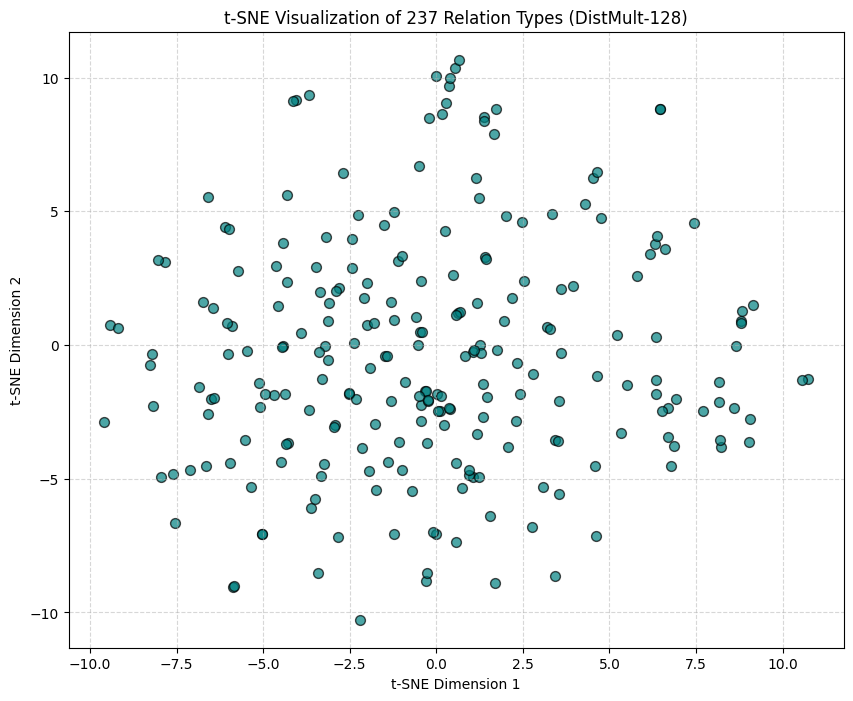

📥 Downloading tsne_relations_rgcn.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from google.colab import files
import numpy as np

print("Extracting 128-Dimension Relation Embeddings...")
# Grab the trained relation weights directly from the model
rel_embs = model.rel_emb.weight.detach().cpu().numpy()

print("Running t-SNE dimensional reduction...")
# Compress 128D to 2D
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
embs_2d = tsne.fit_transform(rel_embs)

# Plotting
plt.figure(figsize=(10, 8))
plt.scatter(embs_2d[:, 0], embs_2d[:, 1], alpha=0.7, c='teal', edgecolors='k', s=50)
plt.title("t-SNE Visualization of 237 Relation Types (DistMult-128)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(True, linestyle='--', alpha=0.5)

# Save the plot
tsne_filename = "tsne_relations_rgcn.png"
plt.savefig(tsne_filename, dpi=300, bbox_inches='tight')
plt.show()

# Download to your computer
print(f"📥 Downloading {tsne_filename}...")
files.download(tsne_filename)

##Error Analysis:

In [ ]:
import pandas as pd
from collections import defaultdict
from tqdm.auto import tqdm
from google.colab import files
import torch

print("Starting Error Analysis by Relation Type...")
model.eval()
rel_mrr_sum = defaultdict(float)
rel_counts = defaultdict(int)

with torch.no_grad():
    # Encode the training graph to get the smart brain
    node_embeddings = model.encode(data.edge_index, data.edge_type)

    num_test_edges = test_data.edge_index.size(1)

    for i in tqdm(range(num_test_edges), desc="Analyzing Errors"):
        h = test_data.edge_index[0, i]
        r = test_data.edge_type[i].item()
        true_t = test_data.edge_index[1, i]

        h_emb = node_embeddings[h].unsqueeze(0)
        t_embs = node_embeddings # All nodes

        # We need r as a tensor for the decode function
        r_tensor = torch.tensor([r], device=device)

        scores = model.decode(h_emb, r_tensor, t_embs)

        sorted_indices = torch.argsort(scores.squeeze(), descending=True)
        rank = (sorted_indices == true_t).nonzero(as_tuple=True)[0].item() + 1

        rel_mrr_sum[r] += 1.0 / rank
        rel_counts[r] += 1

# Compile results into a dataframe
results = []
for r in rel_counts:
    # Only consider relations that appeared at least 10 times in the test set to be fair
    if rel_counts[r] >= 10:
        results.append({
            'Relation_ID': r,
            'Test_Count': rel_counts[r],
            'MRR': rel_mrr_sum[r] / rel_counts[r]
        })

df = pd.DataFrame(results).sort_values(by='MRR', ascending=False)

print("\n🏆 Top 5 EASIEST Relations (Model excels here):")
print(df.head().to_string(index=False))

print("\n🛑 Top 5 HARDEST Relations (Model fails here):")
print(df.tail().to_string(index=False))

# Save and Download
csv_filename = "rgcn_error_analysis.csv"
df.to_csv(csv_filename, index=False)
print(f"\n📥 Downloading {csv_filename}...")
files.download(csv_filename)

Starting Error Analysis by Relation Type...


Analyzing Errors:   0%|          | 0/20466 [00:00<?, ?it/s]


🏆 Top 5 EASIEST Relations (Model excels here):
 Relation_ID  Test_Count  MRR
          33          46  1.0
         110          22  1.0
         167          22  1.0
         195          20  1.0
         120          84  1.0

🛑 Top 5 HARDEST Relations (Model fails here):
 Relation_ID  Test_Count      MRR
          87          46 0.001550
          63          70 0.001222
         161          53 0.000968
         228          10 0.000800
         165          11 0.000694

📥 Downloading rgcn_error_analysis.csv...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>